In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset

In [2]:
df_train = pd.read_csv('yelp_reviews/train.csv')
df_test = pd.read_csv('yelp_reviews/test.csv')

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 560000 entries, 0 to 559999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    560000 non-null  str  
 1   label   560000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 8.5 MB


In [4]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    38000 non-null  str  
 1   label   38000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 593.9 KB


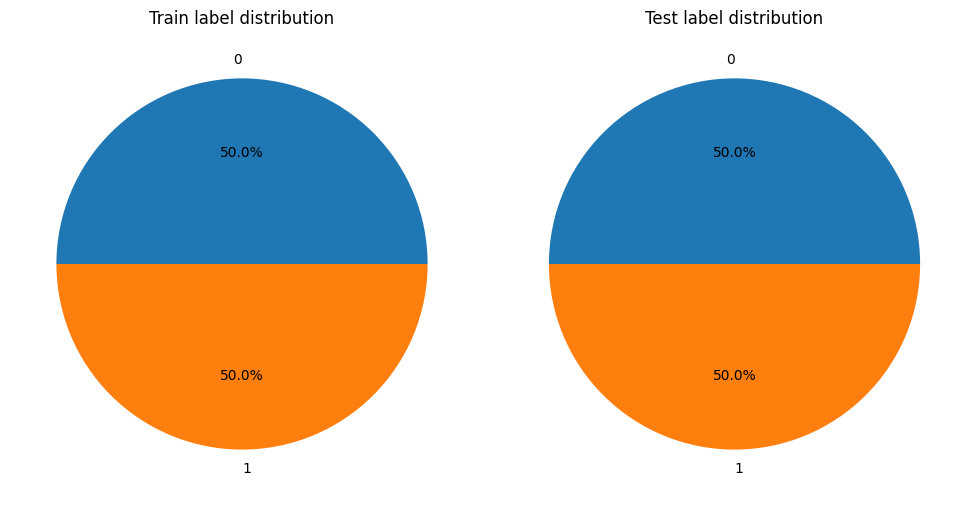

In [5]:
import matplotlib.pyplot as plt

# Count class distribution
train_counts = df_train['label'].value_counts().sort_index()
test_counts = df_test['label'].value_counts().sort_index()

# Create side-by-side pies
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%')
axes[0].set_title('Train label distribution')

axes[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%')
axes[1].set_title('Test label distribution')

plt.tight_layout()
plt.show()

# Preprocessing

In [6]:
import re

# regex obrasci
URL_RE = re.compile(r"http\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
WS_RE = re.compile(r"\s+")

def preprocess_text(text: str) -> str:
    text = str(text).lower()                 # lowercase
    text = URL_RE.sub(" ", text)             # remove URLs
    text = HTML_RE.sub(" ", text)            # remove HTML
    text = WS_RE.sub(" ", text).strip()      # remove extra spaces
    return text

In [7]:
df_train["text_clean"] = df_train["text"].map(preprocess_text)
df_test["text_clean"]  = df_test["text"].map(preprocess_text)

In [8]:
df_train[["text", "text_clean"]].head()

,text,text_clean
0,"Unfortunately, the frustration of being Dr. Go...","unfortunately, the frustration of being dr. go..."
1,Been going to Dr. Goldberg for over 10 years. ...,been going to dr. goldberg for over 10 years. ...
2,I don't know what Dr. Goldberg was like before...,i don't know what dr. goldberg was like before...
3,I'm writing this review to give you a heads up...,i'm writing this review to give you a heads up...
4,All the food is great here. But the best thing...,all the food is great here. but the best thing...


# TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = list(ENGLISH_STOP_WORDS - {"not", "no", "nor", "never"})

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_features=100000,
    stop_words=custom_stopwords,
    sublinear_tf=True
)

In [10]:
X_train = tfidf.fit_transform(df_train["text_clean"])
y_train = df_train["label"].astype(int).values

X_test  = tfidf.transform(df_test["text_clean"])
y_test  = df_test["label"].astype(int).values

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (560000, 100000) X_test: (38000, 100000)


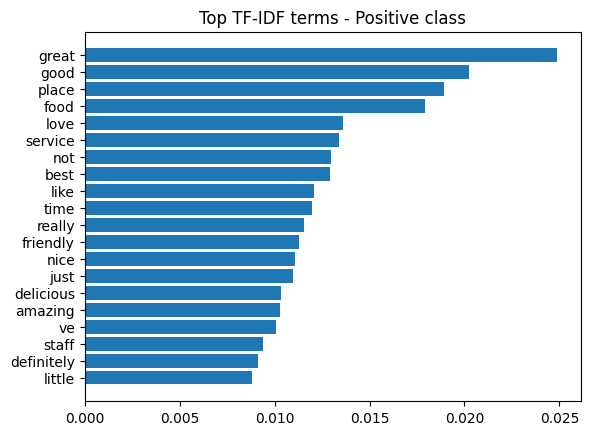

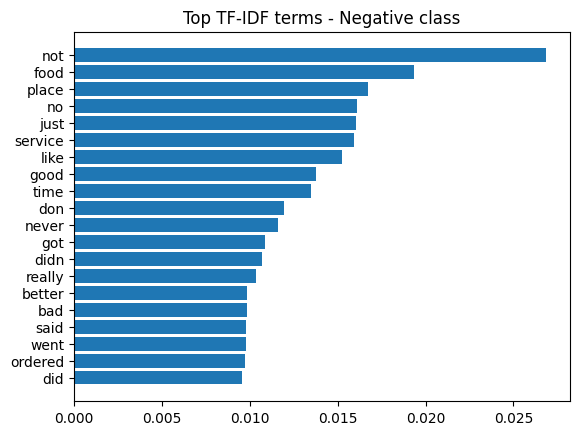

In [11]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = np.array(tfidf.get_feature_names_out())

# odvoji dokumente po klasama
X_pos = X_train[y_train == 1]
X_neg = X_train[y_train == 0]

# srednja TF-IDF vrednost po klasi
mean_tfidf_pos = np.asarray(X_pos.mean(axis=0)).ravel()
mean_tfidf_neg = np.asarray(X_neg.mean(axis=0)).ravel()

# top 20 reči
top_pos_idx = mean_tfidf_pos.argsort()[-20:]
top_neg_idx = mean_tfidf_neg.argsort()[-20:]

plt.figure()
plt.barh(feature_names[top_pos_idx], mean_tfidf_pos[top_pos_idx])
plt.title("Top TF-IDF terms - Positive class")
plt.show()

plt.figure()
plt.barh(feature_names[top_neg_idx], mean_tfidf_neg[top_neg_idx])
plt.title("Top TF-IDF terms - Negative class")
plt.show()

# Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

lr = LogisticRegression(max_iter=2000)

start = time.time()
lr.fit(X_train, y_train)
train_time_lr = time.time() - start

start = time.time()
y_pred_lr = lr.predict(X_test)
test_time_lr = time.time() - start

print("Train time:", round(train_time_lr,2), "s")
print("Test time:", round(test_time_lr,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Train time: 2.78 s
Test time: 0.01 s
Accuracy: 0.939
Macro F1: 0.9389999993240997

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     19000
           1       0.94      0.94      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000

Confusion matrix:
[[17843  1157]
 [ 1161 17839]]


In [13]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

top_pos = np.argsort(coefs)[-20:]
top_neg = np.argsort(coefs)[:20]

print("Top positive words:")
print(feature_names[top_pos])

print("\nTop negative words:")
print(feature_names[top_neg])

Top positive words:
['not disappointed' 'happy' 'enjoyed' 'friendly' 'yummy' 'wonderful'
 'not bad' 'favorite' 'good' 'loved' 'love' 'definitely' 'fantastic'
 'best' 'great' 'perfect' 'excellent' 'awesome' 'amazing' 'delicious']

Top negative words:
['worst' 'bland' 'horrible' 'mediocre' 'terrible' 'not' 'rude'
 'disappointing' 'not worth' 'overpriced' 'awful' 'meh' 'poor' 'dry'
 'disappointed' 'not good' 'ok' 'not great' 'disappointment' 'dirty']


# Linear SVM

In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

svm = LinearSVC()

start = time.time()
svm.fit(X_train, y_train)
train_time_svm = time.time() - start

start = time.time()
y_pred_svm = svm.predict(X_test)
test_time_svm = time.time() - start

print("Train time:", round(train_time_svm,2), "s")
print("Test time:", round(test_time_svm,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Train time: 15.28 s
Test time: 0.01 s
Accuracy: 0.9463947368421053
Macro F1: 0.9463947368049825

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     19000
           1       0.95      0.95      0.95     19000

    accuracy                           0.95     38000
   macro avg       0.95      0.95      0.95     38000
weighted avg       0.95      0.95      0.95     38000

Confusion matrix:
[[17981  1019]
 [ 1018 17982]]


In [15]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coefs = svm.coef_[0]

top_pos = np.argsort(coefs)[-20:]
top_neg = np.argsort(coefs)[:20]

print("Top positive words:")
print(feature_names[top_pos])

print("\nTop negative words:")
print(feature_names[top_neg])

Top positive words:
['pleased' 'yum' 'just right' 'no charge' 'not disappoint' 'good'
 'wasn disappointed' 'perfect' 'fantastic' 'love' 'never bad' 'awesome'
 'excellent' 'best' 'amazing' 'never disappointed' 'great' 'delicious'
 'won disappointed' 'not disappointed']

Top negative words:
['worst' 'not worth' 'not impressed' 'bland' 'wanted like' 'mediocre'
 'disappointed' 'experienced better' 'wanted love' 'meh' 'horrible'
 'disappointing' 'terrible' 'not returning' 'n2 stars' 'used love'
 'underwhelmed' 'wasn impressed' 'not' 'awful']


# Naive Bayes

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

nb = MultinomialNB(alpha=1.0)  # alpha = Laplace smoothing

start = time.time()
nb.fit(X_train, y_train)
train_time_nb = time.time() - start

start = time.time()
y_pred_nb = nb.predict(X_test)
test_time_nb = time.time() - start

print("Train time:", round(train_time_nb,2), "s")
print("Test time:", round(test_time_nb,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Macro F1:", f1_score(y_test, y_pred_nb, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_nb))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Train time: 0.29 s
Test time: 0.02 s
Accuracy: 0.9119473684210526
Macro F1: 0.9119431182739413

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     19000
           1       0.91      0.92      0.91     19000

    accuracy                           0.91     38000
   macro avg       0.91      0.91      0.91     38000
weighted avg       0.91      0.91      0.91     38000

Confusion matrix:
[[17195  1805]
 [ 1541 17459]]


# Passive-Aggressive Classifier

In [17]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

pa = SGDClassifier(
    loss="hinge",        # isto kao linear SVM / passive aggressive
    penalty=None,
    learning_rate="pa1",
    eta0=1.0,
    max_iter=2000,
    random_state=42
)

start = time.time()
pa.fit(X_train, y_train)
train_time_pa = time.time() - start

start = time.time()
y_pred_pa = pa.predict(X_test)
test_time_pa = time.time() - start

print("Train time:", round(train_time_pa,2), "s")
print("Test time:", round(test_time_pa,2), "s")

print("Accuracy:", accuracy_score(y_test, y_pred_pa))
print("Macro F1:", f1_score(y_test, y_pred_pa, average="macro"))

print("\nClassification report:")
print(classification_report(y_test, y_pred_pa))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_pa))

Train time: 8.37 s
Test time: 0.01 s
Accuracy: 0.9265
Macro F1: 0.9264998346246278

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     19000
           1       0.93      0.93      0.93     19000

    accuracy                           0.93     38000
   macro avg       0.93      0.93      0.93     38000
weighted avg       0.93      0.93      0.93     38000

Confusion matrix:
[[17632  1368]
 [ 1425 17575]]


# Confusion matrix

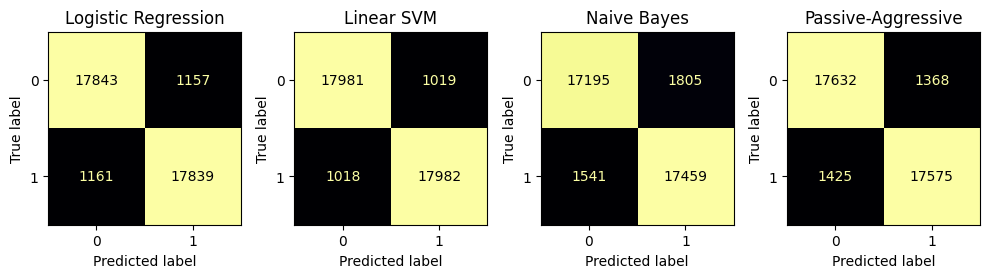

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# figure sa 3 matrice
fig, axes = plt.subplots(1, 4, figsize=(10,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False, values_format='d', cmap="inferno")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[1], colorbar=False, values_format='d', cmap="inferno")
axes[1].set_title("Linear SVM")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=axes[2], colorbar=False, values_format='d', cmap="inferno")
axes[2].set_title("Naive Bayes")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pa, ax=axes[3], colorbar=False, values_format='d', cmap="inferno")
axes[3].set_title("Passive-Aggressive")

plt.tight_layout()
plt.show()

# Word cloud

## Linear Regression

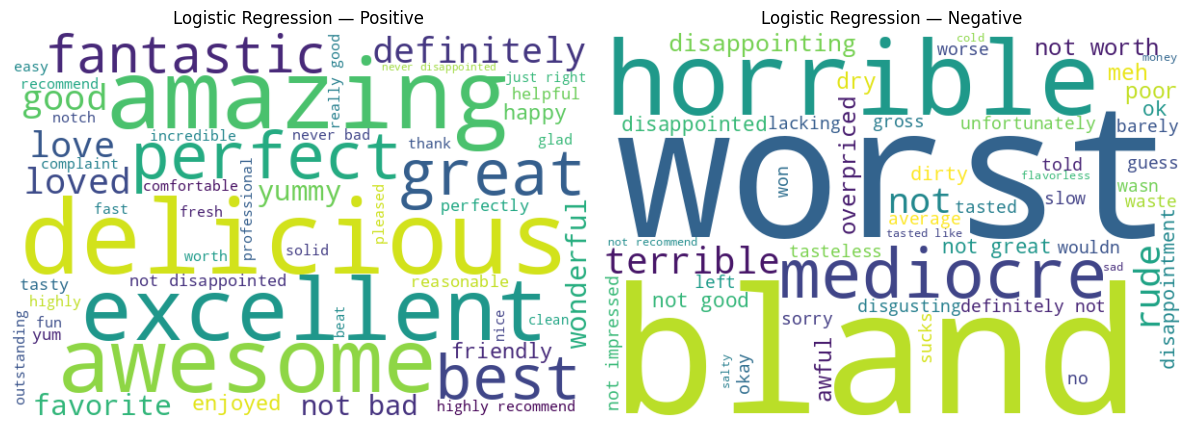

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

feature_names = tfidf.get_feature_names_out()

def wc_linear_side_by_side(model, feature_names, model_name, top_n=50):
    w = model.coef_.ravel()

    pos_idx = np.argsort(w)[-top_n:]
    neg_idx = np.argsort(w)[:top_n]

    pos_freq = {feature_names[i]: float(w[i]) for i in pos_idx if w[i] > 0}
    neg_freq = {feature_names[i]: float(-w[i]) for i in neg_idx if w[i] < 0}

    wc_pos = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(pos_freq)

    wc_neg = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(neg_freq)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].set_title(f"{model_name} — Positive")
    axes[0].axis("off")

    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].set_title(f"{model_name} — Negative")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# LR
wc_linear_side_by_side(lr, feature_names, "Logistic Regression")

## Linear SVM

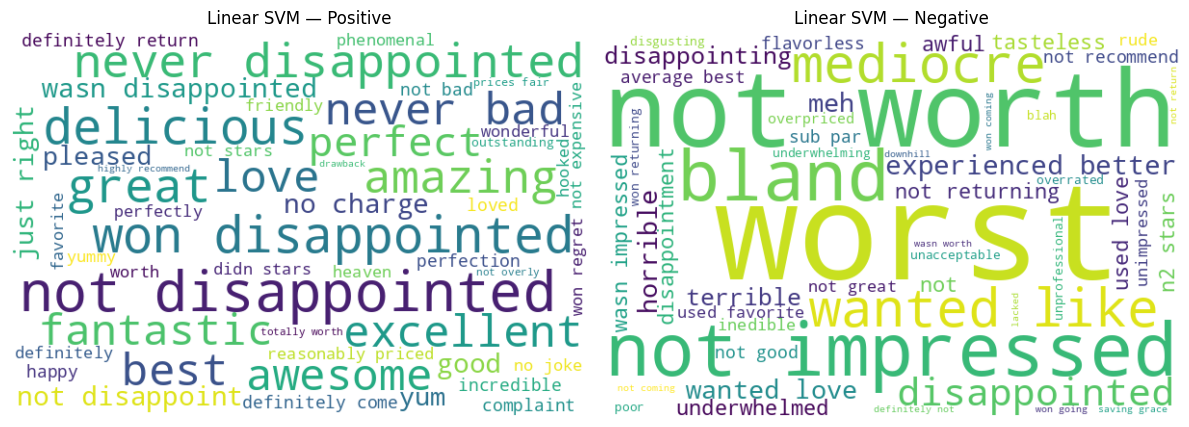

In [20]:
wc_linear_side_by_side(svm, feature_names, "Linear SVM")

## Naive Bayes

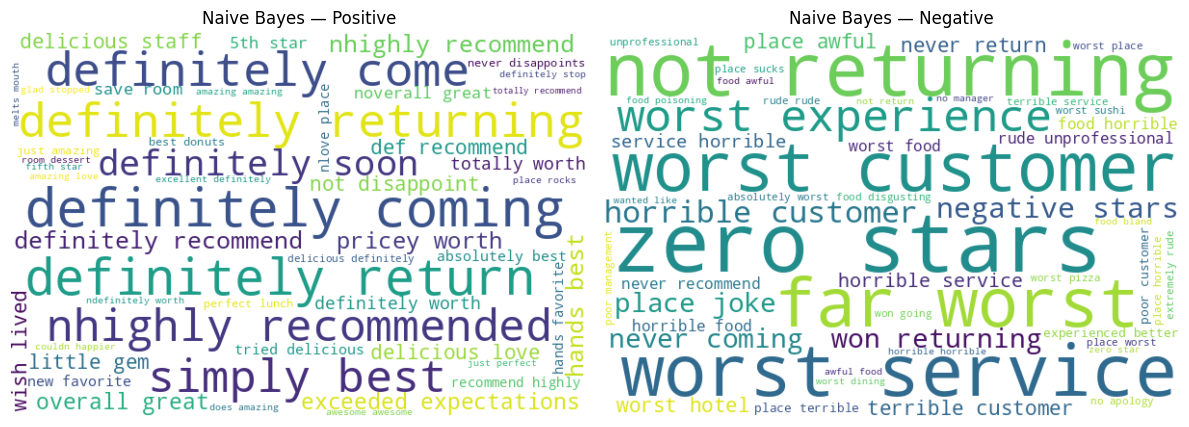

In [21]:
def wc_nb_side_by_side(nb, feature_names, model_name="Naive Bayes", top_n=50):
    diff = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]

    pos_idx = np.argsort(diff)[-top_n:]
    neg_idx = np.argsort(diff)[:top_n]

    pos_freq = {feature_names[i]: float(diff[i]) for i in pos_idx if diff[i] > 0}
    neg_freq = {feature_names[i]: float(-diff[i]) for i in neg_idx if diff[i] < 0}

    wc_pos = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(pos_freq)

    wc_neg = WordCloud(width=600, height=400, background_color="white",
                       collocations=False).generate_from_frequencies(neg_freq)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].set_title(f"{model_name} — Positive")
    axes[0].axis("off")

    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].set_title(f"{model_name} — Negative")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

wc_nb_side_by_side(nb, feature_names)

## Passive-Aggressive Classifier

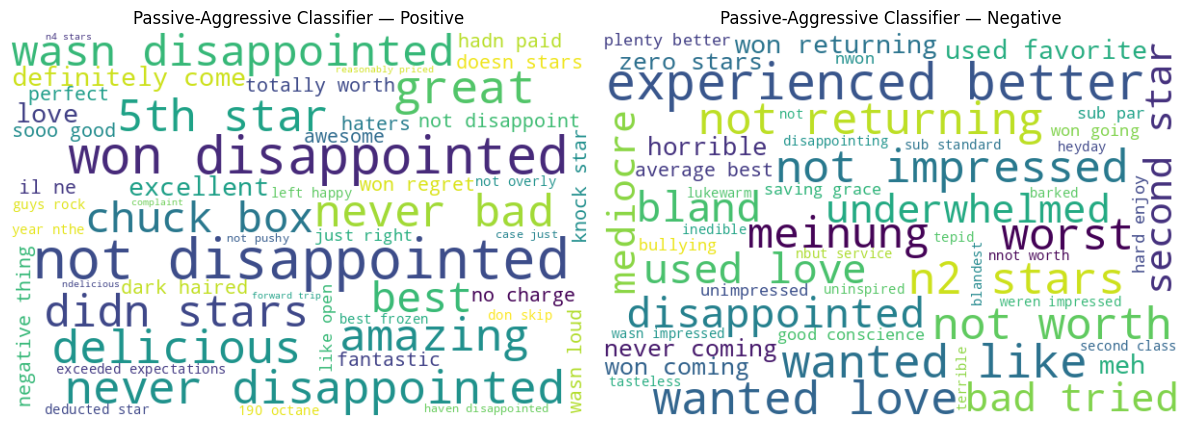

In [22]:
wc_linear_side_by_side(pa, feature_names, "Passive-Aggressive Classifier")

# Comparison

In [23]:
from sklearn.metrics import accuracy_score

print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Linear SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Passive-Aggressive accuracy:", accuracy_score(y_test, y_pred_pa))

Logistic Regression accuracy: 0.939
Linear SVM accuracy: 0.9463947368421053
Naive Bayes accuracy: 0.9119473684210526
Passive-Aggressive accuracy: 0.9265


# Amazon reviews

In [24]:
df_test_amz = pd.read_csv('amazon_reviews/test_sub.csv')

## Preprocessing

In [25]:
df_test_amz["text_clean"]  = df_test_amz["text"].map(preprocess_text)
y_test_amz  = df_test_amz["label"].astype(int).values

X_test_amz_on_yelp = tfidf.transform(df_test_amz["text_clean"])

## Linear Regression

In [26]:
y_pred = lr.predict(X_test_amz_on_yelp)

print("Yelp→Amazon Accuracy:", accuracy_score(y_test_amz, y_pred))
print("Yelp→Amazon Macro F1:", f1_score(y_test_amz, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_amz, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_amz, y_pred))

Yelp→Amazon Accuracy: 0.8320526315789474
Yelp→Amazon Macro F1: 0.8275141396641758

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80     15200
           1       0.88      0.83      0.86     22800

    accuracy                           0.83     38000
   macro avg       0.82      0.83      0.83     38000
weighted avg       0.84      0.83      0.83     38000

Confusion matrix:
[[12727  2473]
 [ 3909 18891]]


## Linear SVM

In [27]:
y_pred = svm.predict(X_test_amz_on_yelp)

print("Yelp→Amazon Accuracy:", accuracy_score(y_test_amz, y_pred))
print("Yelp→Amazon Macro F1:", f1_score(y_test_amz, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_amz, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_amz, y_pred))

Yelp→Amazon Accuracy: 0.8357105263157895
Yelp→Amazon Macro F1: 0.8311411639988904

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80     15200
           1       0.89      0.83      0.86     22800

    accuracy                           0.84     38000
   macro avg       0.83      0.84      0.83     38000
weighted avg       0.84      0.84      0.84     38000

Confusion matrix:
[[12753  2447]
 [ 3796 19004]]


## Naive Bayes

In [28]:
y_pred = nb.predict(X_test_amz_on_yelp)

print("Yelp→Amazon Accuracy:", accuracy_score(y_test_amz, y_pred))
print("Yelp→Amazon Macro F1:", f1_score(y_test_amz, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_amz, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_amz, y_pred))

Yelp→Amazon Accuracy: 0.7814736842105263
Yelp→Amazon Macro F1: 0.7798494340694935

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.87      0.76     15200
           1       0.89      0.72      0.80     22800

    accuracy                           0.78     38000
   macro avg       0.78      0.80      0.78     38000
weighted avg       0.81      0.78      0.78     38000

Confusion matrix:
[[13216  1984]
 [ 6320 16480]]


## Passive-Aggressive Classifier

In [29]:
y_pred = pa.predict(X_test_amz_on_yelp)

print("Yelp→Amazon Accuracy:", accuracy_score(y_test_amz, y_pred))
print("Yelp→Amazon Macro F1:", f1_score(y_test_amz, y_pred, average="macro"))

print("\nClassification report:")
print(classification_report(y_test_amz, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test_amz, y_pred))

Yelp→Amazon Accuracy: 0.7952894736842105
Yelp→Amazon Macro F1: 0.7903773517632535

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76     15200
           1       0.86      0.79      0.82     22800

    accuracy                           0.80     38000
   macro avg       0.79      0.80      0.79     38000
weighted avg       0.80      0.80      0.80     38000

Confusion matrix:
[[12202  2998]
 [ 4781 18019]]


## Confusion matrix

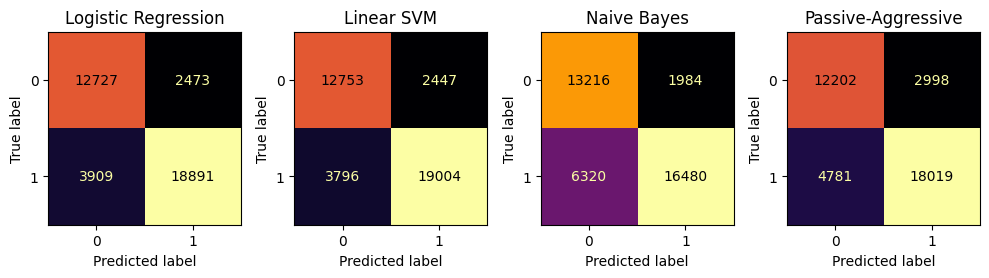

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# predikcije (ako već nisu napravljene)
y_pred_amz_lr  = lr.predict(X_test_amz_on_yelp)
y_pred_amz_svm = svm.predict(X_test_amz_on_yelp)
y_pred_amz_nb  = nb.predict(X_test_amz_on_yelp)
y_pred_amz_pa  = pa.predict(X_test_amz_on_yelp)

# figure sa 3 matrice
fig, axes = plt.subplots(1, 4, figsize=(10,5))

ConfusionMatrixDisplay.from_predictions(y_test_amz, y_pred_amz_lr, ax=axes[0], colorbar=False, values_format='d', cmap="inferno")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test_amz, y_pred_amz_svm, ax=axes[1], colorbar=False, values_format='d', cmap="inferno")
axes[1].set_title("Linear SVM")

ConfusionMatrixDisplay.from_predictions(y_test_amz, y_pred_amz_nb, ax=axes[2], colorbar=False, values_format='d', cmap="inferno")
axes[2].set_title("Naive Bayes")

ConfusionMatrixDisplay.from_predictions(y_test_amz, y_pred_amz_pa, ax=axes[3], colorbar=False, values_format='d', cmap="inferno")
axes[3].set_title("Passive-Aggressive")

plt.tight_layout()
plt.show()